<a href="https://colab.research.google.com/github/sgslay/sgslay/blob/main/Copy_of_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Tokenization, Word Embeddings, and Vector Algebra

## Introduction
In this assignment, we will explore the problem of getting from sequences of characters to wordtypes with different meanings. You will implement widely-used algorithms for tokenizing text and computing context-less word embeddings, and perform analysis on the results of running these algorithms.

Learning objectives:
* Understand how byte pair encoding works as a method for tokenizing character sequences, and how it differs from simpler tokenization methods like splitting on whitespace.
* Gain insights on how to compute and interpret language statistics, including Zipf's laws of word frequencies.
* Understand basics of distributional semantics, including basic implementations of word embedding algorithms.
* Learn to use vector algebra as a way of analyzing a space of word embeddings.

**Notes:**
* In your solution, complete the TODO sections. You may add code cells for the report and adjust the documented training settings. Keep function names, signatures, and output filenames unchanged.
* Items marked with a star (★) should be answered in a separate report as a text document with the corresponding item number. You will include your final report as a pdf with your submission.

* Graded functions should use their arguments, imports, other functions/classes, or literal constants; do not depend on top-level training/report variables. Use ordinary Python code cells (no shell commands or IPython magics).

**Submission:**

Submit `submission.zip` to Gradescope. Partial work is accepted: include your notebook
and any report or result files you have completed. Missing work earns no credit for
the affected questions; completed work is still graded. A complete submission contains:

```
hw2.ipynb # your completed jupyter notebook
report.pdf # your written report
results/ # outputs from jupyter notebook
├── skipgram_scores.npy
├── solve_analogy.json
├── W_en_fr.npy
├── W_en_ja.npy
└── ... (and all other generated files)
```

# Setup

**Google Colab:** save your own copy with **File → Save a copy in Drive**. In
**Runtime → Change runtime type**, select runtime version **2026.07** and a GPU
if available (CPU also works). Run the next cell. After the first installation,
follow its message to **Restart session**, then run the cell again and allow
Google Drive access. See [README.md](https://github.com/Louis0324/eecs183-283A-26fall-hw2#readme)
for setup and submission instructions.

**Local Jupyter:** follow the README installation steps, choose the **Python (hw2)**
kernel, and open the notebook from the homework directory.

The setup cell loads the corpus and defines `save_results`. JSON and NumPy
outputs go in `results/`; on Colab, this directory points to
`MyDrive/cs183-hw2/results` so completed outputs survive a runtime reset.


In [1]:
# On Colab, download the homework files and connect persistent storage.
# On a local machine, use the environment described in README.md.
import sys
if "google.colab" in sys.modules:
    import subprocess
    from pathlib import Path
    import os

    repo = Path("/content/cs183-hw2")
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/Louis0324/eecs183-283A-26fall-hw2.git", str(repo)
        ], check=True)
    os.chdir(repo)
    if str(repo) not in sys.path:
        sys.path.insert(0, str(repo))
    from colab_setup import setup
    setup()

import json
import os
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
from itertools import islice
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tokenizers import ByteLevelBPETokenizer
from tokenizers.normalizers import Lowercase
from tqdm import tqdm

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(2)

# Colab uses its assigned GPU when available. Local runs default to CPU.
device = torch.device("cuda:0" if "google.colab" in sys.modules and torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
Path("results").mkdir(exist_ok=True)

def save_results(results, filename):
    if not os.path.exists('results'):
        os.makedirs('results')
    with open(os.path.join('results', filename), "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

# Load the corpus
with open('data/stories.txt', 'r', encoding='utf-8') as f:
    en_corpus = [line.strip() for line in f.readlines()]

print(f"Loaded {len(en_corpus)} corpus lines (some contain multiple sentences).")
print("First 5 lines:", en_corpus[:5])

Mounted at /content/drive
Setup ready. Results are saved in /content/drive/MyDrive/cs183-hw2/results.
Training device: cuda:0
Loaded 10000 corpus lines (some contain multiple sentences).
First 5 lines: ['The Happy Prince.', 'HIGH above the city, on a tall column, stood the statue of the Happy Prince.  He was gilded all over with thin leaves of fine gold, for eyes he had two bright sapphires, and a large red ruby glowed on his sword-hilt.', 'He was very much admired indeed.  “He is as beautiful as a weathercock,” remarked one of the Town Councillors who wished to gain a reputation for having artistic tastes; “only not quite so useful,” he added, fearing lest people should think him unpractical, which he really was not.', '“Why can’t you be like the Happy Prince?” asked a sensible mother of her little boy who was crying for the moon.  “The Happy Prince never dreams of crying for anything.”', '“I am glad there is some one in the world who is quite happy,” muttered a disappointed man as he

## Part 1: Tokenization (25 points)

In this part, you will implement two standard methods for tokenization to convert a sequence of characters into a sequence of tokens.

### Part 1.0: Setup
**Implement:** A helper function that, given a sequence of tokenized sentences, returns a dictionary pairing word types with their counts. Count every occurrence, including repeated tokens within a sentence. For example, `[["a", "b"], ["a"]]` gives `{"a": 2, "b": 1}`; an empty input gives `{}`.

In [2]:
def count_word_types(tokenized_sentences: List[List[str]]) -> Dict[str, int]:
    """
    Given a list of tokenized sentences, return a dictionary mapping each word type to its frequency.
    """
    counts: Dict[str, int] = {}
    for sentence in tokenized_sentences:
        for token in sentence:
            counts[token] = counts.get(token, 0) + 1
    return counts

### Part 1.1: Simple tokenization (10 points)
**Implement:** A function that splits a given input string by whitespace into sequences of tokens.

In [3]:
def simple_tokenize(text: str) -> List[str]:
    """
    Splits on any whitespace, dropping empty fields; preserves case and punctuation.
    """
    return text.split()

In [4]:
simple_sentences = [simple_tokenize(text) for text in en_corpus]
word_counts_output = count_word_types(simple_sentences)

top_10 = sorted(word_counts_output.items(), key=lambda x: -x[1])[:10]
print(top_10)

[('the', 34392), ('and', 24581), ('to', 15159), ('a', 10956), ('he', 9618), ('of', 9241), ('was', 7858), ('in', 6552), ('his', 5785), ('that', 5705)]


**Report:**

First compute `simple_sentences = [simple_tokenize(text) for text in en_corpus]`,
then `word_counts_output = count_word_types(simple_sentences)`.

★ 1.1.1 What are the 10 most frequent wordtypes in this frequency dictionary?

**The 10 most frequent word types are: the (34,392), and (24,581), to (15,159), a (10,956), he (9,618), of (9,241), was (7,858), in (6,552), his (5,785), that (5,705). These are all common function words, consistent with Zipf's law.**

★ 1.1.2 What are two limitations you observe in this simple tokenization method? Include examples that motivate these limitations.

**Limitation 1: Punctuation sticks to words; "dog." and "dog" count as different types.**

**Limitation 2: No case normalization; "The" and "the" are counted separately, inflating the vocabulary.**


### Part 1.2: Byte pair encoding (15 points)
**Implement:** Complete the character-based BPE class below. This teaching version starts with Unicode characters; Part 2 uses a library implementation that starts with bytes.

1. `get_stats(word_freqs)` counts adjacent symbol pairs, weighted by word frequency. Keys in `word_freqs` are space-separated symbols: `{"a a a b": 2}` has pair counts `('a', 'a'): 4` and `('a', 'b'): 2`.
2. `merge(pair, word_freqs)` returns a new frequency dictionary, replacing non-overlapping occurrences from left to right. For example, merging `('a', 'a')` changes `"a a a b"` to `"aa a b"`. Match whole symbols, not substrings.
3. `train` resets previous state and merges the most frequent pair until `len(self.vocab) >= vocab_size` or no pairs remain. Break frequency ties by choosing the lexicographically smallest pair. Keep `self.vocab` as `{integer_id: symbol}` and `self.merges` as `{(left, right): merged_symbol}` in learning order. Retain existing vocabulary entries; add a merged symbol only if it is new. Reject a requested size smaller than the initial character vocabulary.
4. `tokenize` splits on whitespace and applies the learned merges to each word in learning order. Insert the literal token `" "` between words so their boundaries survive. This separator is never merged and does not count toward `vocab_size`. Unseen characters remain character tokens.
5. `decode` joins the tokens. The round trip normalizes whitespace: `decode(tokenize(text)) == " ".join(text.split())`. For example, a tokenizer with no merges maps `"ab  c"` to `["a", "b", " ", "c"]` and decodes to `"ab c"`. Empty text gives `[]` and decodes to `""`.

In [5]:
class BPE():
    """Byte Pair Encoding (BPE) tokenizer."""

    def __init__(self):
        self.merges = {}
        self.vocab = {}

    def get_stats(self, word_freqs):
        """Counts the frequency of pairs in the vocabulary."""
        pairs = defaultdict(int)
        for word, freq in word_freqs.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i + 1])] += freq
        return pairs

    def merge(self, pair, word_freqs):
        """Merges a pair of symbols into a new symbol in the vocabulary."""
        left, right = pair
        merged = left + right
        new_word_freqs = {}
        for word, freq in word_freqs.items():
            symbols = word.split()
            new_symbols = []
            i = 0
            while i < len(symbols):
                if i < len(symbols) - 1 and symbols[i] == left and symbols[i + 1] == right:
                    new_symbols.append(merged)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            new_word = ' '.join(new_symbols)
            new_word_freqs[new_word] = new_word_freqs.get(new_word, 0) + freq
        return new_word_freqs

    def train(self, corpus: list[str], vocab_size: int):
        """Trains the tokenizer on a given corpus."""

        self.merges = {}
        self.vocab = {}

        # 1. Initialize vocabulary and pre-tokenize the corpus
        initial_vocab = set()
        word_freqs = defaultdict(int)

        # Prepare the initial word frequency map
        for text in corpus:
            words = text.strip().split()
            for word in words:
                processed_word = ' '.join(list(word))
                word_freqs[processed_word] += 1
                initial_vocab.update(list(word))

        # The initial vocabulary includes all single characters
        self.vocab = {i: char for i, char in enumerate(sorted(list(initial_vocab)))}

        if vocab_size < len(self.vocab):
            raise ValueError("vocab_size must include all initial characters")

        # 2. Iteratively merge the most frequent pair
        while len(self.vocab) < vocab_size:
            pairs = self.get_stats(word_freqs)
            if not pairs:
                break
            best_pair = min(pairs.items(), key=lambda x: (-x[1], x[0]))[0]
            word_freqs = self.merge(best_pair, word_freqs)
            merged_symbol = best_pair[0] + best_pair[1]
            self.merges[best_pair] = merged_symbol
            if merged_symbol not in self.vocab.values():
                self.vocab[len(self.vocab)] = merged_symbol

    def tokenize(self, text: str) -> list[str]:
      """Tokenizes a new sentence using the learned merge rules."""
      words = text.split()
      result = []
      for idx, word in enumerate(words):
          symbols = list(word)
          for (left, right), merged in self.merges.items():
              new_symbols = []
              i = 0
              while i < len(symbols):
                  if i < len(symbols) - 1 and symbols[i] == left and symbols[i + 1] == right:
                      new_symbols.append(merged)
                      i += 2
                  else:
                      new_symbols.append(symbols[i])
                      i += 1
              symbols = new_symbols
          result.extend(symbols)
          if idx < len(words) - 1:
              result.append(' ')
      return result

    def decode(self, tokens: list[str]) -> str:
        """Decodes a sequence of tokens back into a string."""
        return ''.join(tokens)

#### 💾 Save your results for `BPE`

In [6]:
bpe_tokenizer = BPE()
bpe_tokenizer.train(en_corpus, vocab_size=500)

# Save the learned merges and vocabulary
save_results({str(k): v for k, v in bpe_tokenizer.merges.items()}, 'bpe_merges.json')
save_results(bpe_tokenizer.vocab, 'bpe_vocab.json')
print("Saved results for BPE merges and vocabulary.")

Saved results for BPE merges and vocabulary.


In [7]:
from collections import Counter

bpe_tokenized_sentences = [bpe_tokenizer.tokenize(text) for text in en_corpus]
bpe_token_counts = Counter(
    tok for sent in bpe_tokenized_sentences for tok in sent if tok != " "
)
top_10_bpe = bpe_token_counts.most_common(10)
print(top_10_bpe)

[('the', 35285), (',', 30195), ('and', 26701), ('s', 20350), ('a', 17928), ('to', 17864), ('.', 15017), ('t', 14150), ('he', 12738), ('in', 11956)]


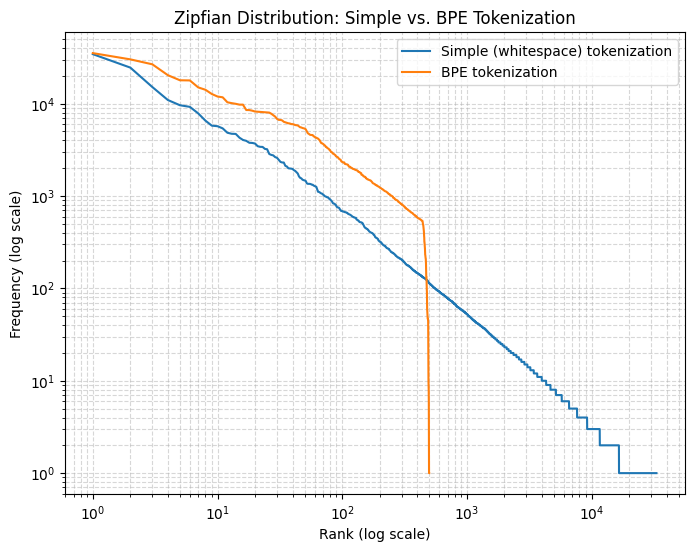

In [8]:
import matplotlib.pyplot as plt

def zipf_ranks_freqs(token_counts):
    freqs = sorted(token_counts.values(), reverse=True)
    ranks = range(1, len(freqs) + 1)
    return ranks, freqs

simple_ranks, simple_freqs = zipf_ranks_freqs(word_counts_output)
bpe_ranks, bpe_freqs = zipf_ranks_freqs(bpe_token_counts)

plt.figure(figsize=(8, 6))
plt.loglog(simple_ranks, simple_freqs, label="Simple (whitespace) tokenization")
plt.loglog(bpe_ranks, bpe_freqs, label="BPE tokenization")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipfian Distribution: Simple vs. BPE Tokenization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig("zipf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Report:**

★ 1.2.1 What are the 10 most frequent token types from your BPE tokenizer? Exclude the literal `" "` boundary token from frequency counts and plots.

**The 10 most frequent BPE token types are (35,285), (30,195), and (26,701), s (20,350), a (17,928), to (17,864), . (15,017), t (14,150), he (12,738), in (11,956).**

★ 1.2.2 Generate a plot showing the Zipfian distribution of wordtypes (i.e., a log-log plot of frequency vs. rank). Compare the distributions from simple whitespace tokenization and BPE, using the full corpus for both. Include the plots and your comparison in the report, make sure your plot is clearly labeled.

**BPE's distribution cuts off around rank 500 due to its fixed vocabulary cap, while whitespace tokenization extends to 10-1000s of ranks with no limit. At low ranks, BPE tokens have higher frequencies than whitespace tokens, since BPE concentrates corpus mass onto fewer subword units. Both curves show the roughly linear trend expected under Zipf's law in their overlapping range.**

★ 1.2.3 Why might these distributions look different from one another?

**These distributions differ because whitespace tokenization produces an open-ended, uncapped vocabulary where every inflection variant is its own type, spreading frequency mass across a very long tail of rare types. BPE has a fixed vocabulary size, so it can't create separate tokens for every surface form, but instead reuses a set of subword units across many contexts. This concentrates frequency onto fewer, more heavily reused tokens.**

## Part 2: Word embeddings (25 points)

In this part, you will implement the Skip-Gram model to compute word embeddings for the words in your corpus.

### Part 2.0: Setup
For the remainder of Part 2, use `ByteLevelBPETokenizer` from the pinned `tokenizers` library. Train it on the full corpus with the settings below; the supplied evaluation arrays use this vocabulary. Save its configuration with your results.

Treat each corpus line as one sequence and never create contexts across line boundaries. The variable `en_tokenized` contains integer token IDs, not strings. For the context comparison in the report, use only `context_corpus = en_tokenized[:100]` for all three settings. This limits the quadratic cost of bag-of-words pairs. Skip-Gram training still uses the full corpus with a local window.

In [9]:
def get_tokenizer(data_path: str, vocab_size=10000):
    tokenizer = ByteLevelBPETokenizer()
    tokenizer.normalizer = Lowercase()

    tokenizer.train(files=data_path, vocab_size=vocab_size, min_frequency=2)

    return tokenizer

en_tokenizer = get_tokenizer("data/stories.txt")
en_tokenized = [en_tokenizer.encode(s).ids for s in en_corpus]
context_corpus = en_tokenized[:100]
en_tokenizer.save("results/en_tokenizer.json")

### Part 2.1: Experiment with different contexts (5 points)
**Implement:** Two functions returning lists of `(target_id, context_id)` pairs.

**a) Bag-of-words context:** For each token position, pair its token with every other position in the same sequence. A sequence of length $m$ contributes $m(m-1)$ pairs. Exclude the target position, not every occurrence of the same token ID: `[[1, 1, 2]]` must contain two `(1, 1)` pairs.

**b) Neighboring-token context:** Pair each target with the tokens at most `window_size` positions to either side. Clip the window at sequence boundaries; do not add BOS/EOS tokens or position labels. For `[[1, 2, 3]]` and a window of 1, return `[(1, 2), (2, 1), (2, 3), (3, 2)]`.

For both functions, visit sequences, target positions, and context positions in their original order, preserving duplicate pairs. Empty and one-token sequences contribute no pairs. A zero window gives no pairs; reject a negative window with `ValueError`.

In [10]:
def get_bow_context(tokenized_sentences: List[List[int]]) -> List[Tuple[int, int]]:
    """
    Creates positive (target, context) examples where context is any other word in the sentence.
    """
    # TODO: Implement this function
    pairs = []
    for sentence in tokenized_sentences:
        for i, target in enumerate(sentence):
            for j, context in enumerate(sentence):
                if i != j:
                    pairs.append((target, context))
    return pairs


def get_neighbor_context(tokenized_sentences: List[List[int]], window_size: int) -> List[Tuple[int, int]]:
    """
    Creates positive (target, context) examples from tokens within a given window size.
    """
    # TODO: Implement this function
    if window_size < 0:
        raise ValueError("window_size must be non-negative")

    pairs = []
    for sentence in tokenized_sentences:
        n = len(sentence)
        for i, target in enumerate(sentence):
            lo = max(0, i - window_size)
            hi = min(n, i + window_size + 1)
            for j in range(lo, hi):
                if j != i:
                    pairs.append((target, sentence[j]))
    return pairs

#### 💾 Save your results for `get_neighbor_context`

In [11]:
neighbor_pairs = get_neighbor_context(context_corpus, window_size=2)
save_results(neighbor_pairs[:10000], 'neighbor_context.json')
print("Saved results for get_neighbor_context.")

Saved results for get_neighbor_context.


### Part 2.2: Negative sampling (5 points)
To train the Skip-Gram model efficiently, we use negative sampling. First, we model the probability distribution over contexts.

**Implement:** A function that computes a distribution over the contexts $\mathcal{C}$ given a dataset of word-context pairs $\mathcal{D}$. Use the empirical context frequency divided by the total number of pairs, with no smoothing or exponent. Include a zero probability for vocabulary IDs that never appear as contexts. Reject an empty pair list with `ValueError`.

In [12]:
def get_context_distribution(pairs: List[Tuple[int, int]], vocab_size: int) -> List[float]:
    """
    Computes the probability distribution over contexts P(c).

    Args:
        pairs: A list of (token, context) pairs.
        vocab_size: The size of the vocabulary.

    Returns:
        A list of probabilities for each context token, ordered by token index.
    """
    # TODO: Implement this function

    if len(pairs) == 0:
        raise ValueError("pairs must not be empty")

    counts = [0] * vocab_size
    for _, context in pairs:
        counts[context] += 1

    total = len(pairs)
    return [c / total for c in counts]


**Implement:** A function for sampling negative pairs of tokens and contexts given the prior over contexts $\mathcal{C}$. Draw independently with replacement, returning a `torch.long` tensor of shape `(batch_size, num_samples)` on the distribution's device. Do not reject a draw just because it matches a positive context; accidental matches are allowed. For example, `[0., 1., 0.]` always samples ID 1.

In [13]:

def sample_negative_contexts(context_distribution: torch.Tensor, num_samples: int, batch_size=1) -> torch.Tensor:
    """
    Samples negative contexts based on the context distribution.
    """
    # TODO: Implement this function

    samples = torch.multinomial(
        context_distribution, num_samples * batch_size, replacement=True
    )
    return samples.view(batch_size, num_samples).to(torch.long)

In [14]:
bow_pairs = get_bow_context(context_corpus)
n1_pairs = get_neighbor_context(context_corpus, window_size=1)
n2_pairs = get_neighbor_context(context_corpus, window_size=2)

vocab_size = en_tokenizer.get_vocab_size()

for name, pairs in [("Bag-of-words", bow_pairs), ("Neighbors N=1", n1_pairs), ("Neighbors N=2", n2_pairs)]:
    dist = torch.tensor(get_context_distribution(pairs, vocab_size))
    top_id = torch.argmax(dist).item()
    print(name, "->", en_tokenizer.decode([top_id]), "prob:", dist[top_id].item())

Bag-of-words ->  the prob: 0.06566493213176727
Neighbors N=1 ->  the prob: 0.0653795525431633
Neighbors N=2 ->  the prob: 0.06553559750318527


**Report:**

★ 2.2.1 For each of the following context settings, list the highest-probability *negative* sample according to the priors you computed on `context_corpus`. Decode the most likely ID and report its probability; do not generate all bag-of-words pairs for the full corpus:
- Context as a bag of words.
- Context as neighboring tokens, $N=1$.
- Context as neighboring tokens, $N=2$.

**- Bag-of-words: "the" (p = 0.0657).**

**- Neighboring tokens (N=1): "the" (p = 0.0654).**

**- Neighboring tokens (N=2): "the" (p = 0.0655).**

### Part 2.3: Train the Skip-Gram model and analyze embeddings (15 points)

Now, we'll define our Skip-Gram model and train it on our corpus.

**Implement:** A Skip-Gram model in PyTorch. The model should consist of two embedding layers: one for the target words and one for the context words, named `target_embeddings` and `context_embeddings`.

`forward` returns dot-product **logits**, without a sigmoid. Targets have shape `(B,)`; contexts may have shape `(B,)` for one context per target or `(B, K)` for several. Return shape `(B,)` or `(B, K)`, respectively. Use target embeddings for the cosine-similarity exercise. Initialize the weights with small values (for example, uniformly in `[-0.5 / embedding_dim, 0.5 / embedding_dim]`) so initial logits stay close to zero.

In [15]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super(SkipGramModel, self).__init__()
        # TODO: Implement the model layers
        bound = 0.5 / embedding_dim
        self.target_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)
        nn.init.uniform_(self.target_embeddings.weight, -bound, bound)
        nn.init.uniform_(self.context_embeddings.weight, -bound, bound)


    def forward(self, target, context):
        # TODO: Implement the forward pass
        target_emb = self.target_embeddings(target)
        context_emb = self.context_embeddings(context)

        if context_emb.dim() == 2:
            logits = (target_emb * context_emb).sum(dim=-1)
        else:
            logits = (target_emb.unsqueeze(1) * context_emb).sum(dim=-1)
        return logits

**Implement:** Complete the training loop. Use the full corpus and a clipped context window of five.

For each batch, draw **10 negative contexts per positive pair** from the empirical context distribution. Place the positive context in column 0 followed by the ten negatives. Use labels 1 for the positive column and 0 for the negative columns, and average `BCEWithLogitsLoss` over all entries. Clear gradients, backpropagate, and update the optimizer each batch.

The supplied dataset stores pairs in compact integer arrays, preparing one corpus line at a time. The defaults are 10 epochs, a batch size of 1024, and learning rate 0.001; CPU is sufficient. You may adjust `batch_size`, `num_epochs`, and `device` while debugging. Start with one epoch on a small corpus, then train on the full corpus for the saved evaluation. Keep the tokenizer settings, embedding dimension, context window, and number of negatives unchanged. Inspect epoch losses to check learning.

In [16]:
class SkipGramDataset(Dataset):
    def __init__(self, tokenized_sentences, window_size=5):
        chunks = []
        for sentence in tokenized_sentences:
            pairs = get_neighbor_context([sentence], window_size)
            if pairs:
                chunks.append(np.asarray(pairs, dtype=np.int32))
        self.pairs = np.concatenate(chunks) if chunks else np.empty((0, 2), dtype=np.int32)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx].astype(np.int64)


def train_skipgram(corpus, tokenizer, num_epochs=10, batch_size=1024, device="cpu"):
    device = torch.device(device)
    embedding_dim = 128
    vocab_size = len(tokenizer.get_vocab())
    model = SkipGramModel(vocab_size, embedding_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    dataset = SkipGramDataset((tokenizer.encode(s).ids for s in corpus), window_size=5)
    if len(dataset) == 0:
        raise ValueError("Training requires at least one target/context pair")
    context_distribution = torch.tensor(
        get_context_distribution(dataset.pairs, vocab_size), dtype=torch.float32, device=device
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    num_negatives = 10

    # TODO: Implement the training loop and print the average loss each epoch.
    # Each batch is an integer tensor of shape (B, 2): target IDs, context IDs.

    for epoch in range(num_epochs):
        total_loss = 0.0
        n_batches = 0
        for batch in dataloader:
            batch = batch.to(device)
            target_ids = batch[:, 0]
            pos_context = batch[:, 1]

            neg_context = sample_negative_contexts(
                context_distribution, num_negatives, batch_size=target_ids.size(0)
            ).to(device)

            contexts = torch.cat([pos_context.unsqueeze(1), neg_context], dim=1)  # (B, 1+K)
            labels = torch.zeros_like(contexts, dtype=torch.float32)
            labels[:, 0] = 1.0

            optimizer.zero_grad()
            logits = model(target_ids, contexts)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        print(f"Epoch {epoch + 1}/{num_epochs} - avg loss: {total_loss / n_batches:.4f}")


    return model

#### 💾 Save your model outputs

In [17]:
model = train_skipgram(en_corpus, en_tokenizer, num_epochs=10, batch_size=1024, device=device)

test_center_word = torch.from_numpy(np.load("data/center_word.npy")).long()
test_context_words = torch.from_numpy(np.load("data/context_words.npy")).long()

# Evaluate in small batches instead of allocating all 65,536 examples on the device.
model.eval()
model_device = next(model.parameters()).device
test_scores = []
with torch.no_grad():
    for start in range(0, len(test_center_word), 1024):
        scores = model(
            test_center_word[start:start + 1024].to(model_device),
            test_context_words[start:start + 1024].to(model_device),
        )
        test_scores.append(scores.cpu())
test_scores = torch.cat(test_scores).numpy()
assert test_scores.shape == test_context_words.shape
assert np.isfinite(test_scores).all()
np.save("results/skipgram_scores.npy", test_scores)

Epoch 1/10 - avg loss: 0.3069
Epoch 2/10 - avg loss: 0.2927
Epoch 3/10 - avg loss: 0.2893
Epoch 4/10 - avg loss: 0.2869
Epoch 5/10 - avg loss: 0.2850
Epoch 6/10 - avg loss: 0.2835
Epoch 7/10 - avg loss: 0.2821
Epoch 8/10 - avg loss: 0.2811
Epoch 9/10 - avg loss: 0.2802
Epoch 10/10 - avg loss: 0.2794


**Implement:** A function that, given a trained Skip-Gram model and a target wordtype, returns the cosine similarity of that wordtype's embedding with the embedding of every other wordtype in the vocabulary. Here `target_word` must be an **exact tokenizer vocabulary entry** (use `tokenizer.get_vocab()` to inspect entries; `Ġ` marks a leading space). Look up its ID directly rather than encoding and taking the first subword. Raise `ValueError` if the entry is missing. Return all other raw token strings, sorted by descending similarity; break ties by token ID. Define cosine similarity with a zero vector as 0.

In [18]:
def get_cosine_similarity(model: SkipGramModel, tokenizer: ByteLevelBPETokenizer, target_word: str) -> List[Tuple[str, float]]:
    """
    Given a trained model and a target word, returns a list of (word, similarity_score)
    for all words in the vocabulary (excluding the target word), sorted by similarity score.
    """
    # TODO: Implement this function
    vocab = tokenizer.get_vocab()
    if target_word not in vocab:
        raise ValueError(f"'{target_word}' is not in the tokenizer vocabulary")

    target_id = vocab[target_word]
    device = next(model.parameters()).device

    all_embs = model.target_embeddings.weight.detach()
    target_emb = all_embs[target_id]

    norms = all_embs.norm(dim=1)
    target_norm = target_emb.norm()
    denom = norms * target_norm
    dots = all_embs @ target_emb
    sims = torch.where(denom > 0, dots / denom, torch.zeros_like(dots))

    id_to_token = {idx: tok for tok, idx in vocab.items()}
    results = [
        (id_to_token[idx], sims[idx].item())
        for idx in range(len(vocab))
        if idx != target_id
    ]
    results.sort(key=lambda pair: (-pair[1], vocab[pair[0]]))
    return results

In [20]:
for word in ["king", "happy", "dog", "run", "city"]:
    vocab_word = "Ġ" + word
    if vocab_word not in en_tokenizer.get_vocab():
        print(word, "-> not in vocab (even with Ġ prefix)")
        continue
    sims = get_cosine_similarity(model, en_tokenizer, vocab_word)
    print(word, "->", sims[:5])

king -> [('Ġgardener', 0.505573570728302), ('Ġraja', 0.48071563243865967), ('Ġminister', 0.4787682592868805), ('Ġsoothsayer', 0.4648495018482208), ('Ġhuntsman', 0.46476009488105774)]
happy -> [('Ġcontented', 0.5524411201477051), ('Ġdelightful', 0.46125903725624084), ('Ġsad', 0.4600648880004883), ('Ġthoughtful', 0.4592439830303192), ('Ġsorry', 0.4502807557582855)]
dog -> [('Ġwolf', 0.4406190812587738), ('Ġcock', 0.44053754210472107), ('anges', 0.43822649121284485), ('Ġrabbit', 0.43053993582725525), ('Ġcat', 0.42659181356430054)]
run -> [('Ġdrive', 0.5150480270385742), ('Ġdrag', 0.4830511808395386), ('Ġgo', 0.46158990263938904), ('Ġlimped', 0.4532962143421173), ('Ġswam', 0.43809083104133606)]
city -> [('Ġsimons', 0.5629339814186096), ('Ġtown', 0.5404362678527832), ('Ġcountry', 0.5383481979370117), ('Ġparty', 0.5268142223358154), ('Ġpalace', 0.515333354473114)]


**Report:**

★ 2.3.1 Use `get_cosine_similarity` to explore similar wordtypes for different English words. Give three examples of pairs of similar wordtypes that make sense, and three that don't. What are possible reasons for a high similarity score between two seemingly unrelated words?

**Pairs that make sense: "dog"–"cat", "happy"–"delightful", "city"–"town" — share semantic category and probably appear in similar contexts.**

**Pairs that don't make sense: "run"–"drive", "king"–"gardener", "dog"–"anges" — no clear semantic link even though they have high scores.**

**High similarity between unrelated words happens because Skip-Gram captures co-occurrence, not meaning, so words in similar syntactic positions get similar vectors even if their meanings differ.**


## Part 3: Vector algebra (25 points)
Use the pinned spaCy models installed with `pip install -r requirements-models.txt` (see README.md). All three have 300-dimensional vectors. The helpers below use vector-backed vocabulary entries, not whichever lexemes happen to have been visited by the NLP pipeline.

### Part 3.0: Setup

In [22]:
import spacy

nlp_en = spacy.load("en_core_web_md")
nlp_fr = spacy.load("fr_core_news_md")
nlp_ja = spacy.load("ja_core_news_md")


def nearest_vector_words(nlp, vector, n=1, exclude=()):
    """Return up to n (word, cosine) matches from finite, nonzero vector rows."""
    vector = np.asarray(vector, dtype=np.float64)
    norm = np.linalg.norm(vector)
    if not np.isfinite(norm) or norm == 0:
        raise ValueError("The query must have a finite, nonzero vector")
    data = nlp.vocab.vectors.data
    norms = np.linalg.norm(data, axis=1)
    valid = np.isfinite(data).all(axis=1) & (norms > 0)
    similarities = np.full(len(data), -np.inf)
    similarities[valid] = (data[valid] @ (vector / norm)) / norms[valid]
    # Use the first stored key for each row, not an arbitrary pruned alias.
    excluded = {word.casefold() for word in exclude}
    row_words, excluded_rows = {}, set()
    for key, row in nlp.vocab.vectors.key2row.items():
        word = nlp.vocab.strings[key]
        if word.casefold() in excluded:
            excluded_rows.add(row)
        if valid[row]:
            row_words.setdefault(row, word)
    # Exclude input rows as well: an alias must not reintroduce an input vector.
    rows = sorted((row for row in row_words if row not in excluded_rows),
                  key=lambda row: (-similarities[row], row_words[row]))
    return [(row_words[row], float(similarities[row])) for row in rows[:n]]

### Part 3.1: Word analogy (10 points)

**Implement:** A function that, given two wordtypes representing a target analogy (e.g., *cat* and *kitten*) and an input wordtype to evaluate in that analogy (e.g., *dog*), returns the wordtype that (according to the learned embeddings) best fits as the analogy. Use cosine similarity to `vec(b) - vec(a) + vec(c)`. Exclude all three input words (case-insensitively) and their shared vector rows, reject missing/zero input vectors with `ValueError`, and return one best word as a string. The optional `n` controls how many candidates the supplied `nearest_vector_words` helper retrieves; it does not change the return type. You may call that helper. Analogy predictions need not match the illustrative expected words exactly; report both successes and failures.

In [23]:
def solve_analogy(model, a: str, b: str, c: str, n=5) -> str:
    """
    Solves the analogy 'a is to b as c is to ?'.
    Returns the word from the vocabulary whose embedding is closest to vec(b) - vec(a) + vec(c).
    """
    # TODO: Implement this function
    vocab = model.vocab
    words = {}
    for w in (a, b, c):
        lex = vocab[w]
        if not lex.has_vector or not np.isfinite(lex.vector).all() or np.linalg.norm(lex.vector) == 0:
            raise ValueError(f"'{w}' has no usable vector")
        words[w] = lex.vector

    target_vector = words[b] - words[a] + words[c]
    matches = nearest_vector_words(model, target_vector, n=n, exclude=(a, b, c))
    if not matches:
        raise ValueError("No candidate words found")
    return matches[0][0]

#### 💾 Save your results for `solve_analogy`

In [24]:
test_analogies = [
    ("king", "queen", "man", "woman"),
    ("paris", "france", "berlin", "germany"),
    ("car", "driver", "train", "conductor"),
    ("good", "better", "bad", "worse"),
    ("big", "bigger", "small", "smaller"),
    ("dog", "puppy", "cat", "kitty"),
]


analogy_results = []
for a, b, c, expected in test_analogies:
    result = solve_analogy(nlp_en, a, b, c)
    analogy_results.append(result)
    print(f"{a}:{b}::{c}:? -> {result} (expected: {expected})")

save_results(analogy_results, 'solve_analogy.json')

king:queen::man:? -> lady (expected: woman)
paris:france::berlin:? -> Germany (expected: germany)
car:driver::train:? -> trains (expected: conductor)
good:better::bad:? -> worse (expected: worse)
big:bigger::small:? -> smaller (expected: smaller)
dog:puppy::cat:? -> kitty (expected: kitty)


**Report:**

★ 3.1.1 Find three analogies in English that the model is able to solve correctly, and three analogies in English where the model gives a wrong answer.

**Correct:**
> **paris:france::berlin:? → Germany**

> **good:better::bad:? → worse**

> **8big:bigger::small:? → smaller**

**Incorrect:**
> **king:queen::man:? → lady (expected woman)**

> **car:driver::train:? → trains (expected conductor)**

> **dog:puppy::cat:? → kitty (expected kitten)**

### 3.2 Embedding alignment (15 points)

**Implement:** A function that identifies the transformation $W$ that best aligns two embedding spaces given the supplied bilingual word pairs. Use **unconstrained least squares** on normalized vectors (no orthogonality constraint). With examples stored as rows, minimize `||X @ W.T - Y||²`; inference uses `W @ source_vector`. Use `np.linalg.lstsq(..., rcond=None)` or a pseudoinverse rather than inverting `X.T @ X`.

The supplied preprocessing removes exact duplicate pairs and excludes entries without a finite, nonzero single-lexeme vector. In particular, some multiword phrases do not have such a vector. It prints the number of retained pairs so you can see the coverage.

In [25]:
from spacy.language import Language


def learn_translation_matrix(
    nlp_src: Language,
    nlp_tgt: Language,
    word_pairs: List[List[str]]
) -> np.ndarray:
    """Return W of shape (target_dim, source_dim), minimizing ||X @ W.T - Y||²."""
    X_list, Y_list = [], []
    seen = set()
    for src_word, tgt_word in word_pairs:
        if (src_word, tgt_word) in seen:
            continue
        seen.add((src_word, tgt_word))
        src, tgt = nlp_src.vocab[src_word], nlp_tgt.vocab[tgt_word]
        if not (src.has_vector and tgt.has_vector):
            continue
        src_norm, tgt_norm = np.linalg.norm(src.vector), np.linalg.norm(tgt.vector)
        if not (np.isfinite(src_norm) and np.isfinite(tgt_norm) and src_norm > 0 and tgt_norm > 0):
            continue
        X_list.append(src.vector.astype(np.float64) / src_norm)
        Y_list.append(tgt.vector.astype(np.float64) / tgt_norm)
    if not X_list:
        raise ValueError("No usable bilingual vector pairs")
    X, Y = np.asarray(X_list), np.asarray(Y_list)
    print(f"Using {len(X)} of {len(word_pairs)} bilingual pairs")

    # TODO: Solve X @ W.T ≈ Y and return W.
    W_T, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return W_T.T


def translate_with_matrix(nlp_src: Language, nlp_tgt: Language, W: np.ndarray, word: str):
    """Translate a single vocabulary entry using a learned column-vector map."""
    src = nlp_src.vocab[word]
    norm = np.linalg.norm(src.vector)
    if not src.has_vector or not np.isfinite(norm) or norm == 0:
        raise ValueError(f"No usable source vector for {word!r}")
    expected_shape = (nlp_tgt.vocab.vectors_length, nlp_src.vocab.vectors_length)
    if W.shape != expected_shape or not np.isfinite(W).all():
        raise ValueError(f"W must be finite and have shape {expected_shape}")
    matches = nearest_vector_words(nlp_tgt, W @ (src.vector / norm))
    if not matches:
        raise ValueError("No usable target vectors")
    return matches[0][0]

#### 💾 Save your results for `learn_translation_matrix`

In [26]:
with open("data/en-ja.json", encoding="utf-8") as f:
    en_ja = json.load(f)
with open("data/en-fr.json", encoding="utf-8") as f:
    en_fr = json.load(f)

W_en_fr = learn_translation_matrix(nlp_en, nlp_fr, en_fr)
W_en_ja = learn_translation_matrix(nlp_en, nlp_ja, en_ja)

# Save your matrices
np.save('results/W_en_fr.npy', W_en_fr)
np.save('results/W_en_ja.npy', W_en_ja)
print("Saved translation matrices.")

Using 793 of 842 bilingual pairs
Using 649 of 842 bilingual pairs
Saved translation matrices.


**Report:** Generate transformation matrices to translate between English↔Japanese and English↔French. Learn each reverse map by swapping the bilingual pairs and source/target models; do not assume that transposing or inverting a forward map gives the reverse least-squares solution.

★ 3.2.1 What happens when you translate each of these English words to Japanese/French, then back to English?

1. penguin → éléphant → elephant / 海 → ocean
2. cheese → fromage → sausage / 美味しい → delicious
3. sofa → canapé → sofa / ソファー → bed
4. jacket → pantalon → sleeves / 上着 → clothing
5. website → internet → internet / インターネット → internet

> Only "website" was unchanged in both languages. The rest drift to semantically related but distinct words, showing the alignment captures rough semantic neighborhoods rather than exact translations.

In [27]:
en_words = [
    "penguin",
    "cheese",
    "sofa",
    "jacket",
    "website"
]

# TODO: Use this space to translate the words above using your learned matrices.
def roundtrip(word, nlp_mid, W_to_mid, W_back):
    mid_word = translate_with_matrix(nlp_en, nlp_mid, W_to_mid, word)
    back_word = translate_with_matrix(nlp_mid, nlp_en, W_back, mid_word)
    return mid_word, back_word

W_fr_en = learn_translation_matrix(nlp_fr, nlp_en, [[fr, en] for en, fr in en_fr])
W_ja_en = learn_translation_matrix(nlp_ja, nlp_en, [[ja, en] for en, ja in en_ja])

for word in en_words:
    fr_word, back_from_fr = roundtrip(word, nlp_fr, W_en_fr, W_fr_en)
    ja_word, back_from_ja = roundtrip(word, nlp_ja, W_en_ja, W_ja_en)
    print(f"{word}: FR -> {fr_word} -> {back_from_fr} | JA -> {ja_word} -> {back_from_ja}")

Using 793 of 842 bilingual pairs
Using 649 of 842 bilingual pairs
penguin: FR -> éléphant -> elephant | JA -> 海 -> ocean
cheese: FR -> fromage -> sausage | JA -> 美味しい -> delicious
sofa: FR -> canapé -> sofa | JA -> ソファー -> bed
jacket: FR -> pantalon -> sleeves | JA -> 上着 -> clothing
website: FR -> internet -> internet | JA -> インターネット -> internet


## Part 4: Computational linguistics (25 points)
Use spaCy to tokenize, lemmatize, and obtain dependency trees for the **first 1000 nonempty sentences** in the corpus. The helper below uses the English pipeline to segment corpus lines and stops after 1000 sentences. Reuse these parsed sentences for all three report questions.

**Report:**

A *lemma* is the canonical or dictionary form of a word, representing the base from which all its inflected forms are derived. In NLP, the process of lemmatization groups these various forms (e.g., ran, runs, running) under their single shared lemma (run) to normalize text and simplify analysis.

★ 4.1.1 Report the 10 most frequent verb lemmas in these 1000 sentences, counting tokens with `pos_ == "VERB"` (exclude `AUX`).

> **Top 10 verb lemmas: say (204), go (96), have (94), cry (71), come (68), see (54), look (52), give (43), think (42), know (42)**


★ 4.1.2 For the top 5 most frequent verb lemmas, show the distribution of their subject lemmas as counts, aggregating over all occurrences of each verb lemma. For each verb token, inspect its direct children for `dep_ == "nsubj"` or `dep_ == "nsubjpass"`. Use the subject head's lemma. Do not restrict the search to sentence roots or infer omitted/shared subjects; skip verb occurrences without an explicit subject child.

> **say: he (23), Miller (17), Prince (15), Rocket (15), Hans (13), I (11), Swallow (9), Nightingale (5), Giant (5), rat (5)**

> **go: I (22), he (20), you (7), they (6), everybody (3), she (3), it (2), friend (1), eye (1), thorn (1)**

> **have: I (25), he (20), she (9), you (9), they (3), we (3), who (2), mother (1), man (1), it (1)***

> **cry: he (14), Hans (8), they (5), she (4), Nightingale (3), tree (3), Rocket (3), who (2), Tree (2), press (2)**

> **come: you (5), Spring (5), they (4), he (4), Miller (3), I (2), snow (2), Day (2), Giant (2), spring (2)**

★ 4.1.3 Based on your findings, do you observe any relationship between the types of verbs and the types of subjects they take (e.g., are certain verbs more likely to have animate subjects like 'man' or 'I', versus inanimate subjects like 'door' or 'it')? Discuss one interesting example.

>**Most verbs here are dominated by animate/personal subjects. "Cry" is a good example: nearly all its subjects are people or personified animals , since crying requires a subject capable of emotion.**

In [28]:
def first_parsed_sentences(nlp, corpus, limit=1000):
    sentences = []
    for doc in nlp.pipe((line for line in corpus if line.strip()), batch_size=16):
        for sentence in doc.sents:
            if sentence.text.strip():
                sentences.append(sentence)
                if len(sentences) == limit:
                    return sentences
    return sentences


en_corpus_mini = first_parsed_sentences(nlp_en, en_corpus)
print(f"Analyzing {len(en_corpus_mini)} parsed sentences")

# TODO: Count verb lemmas and the subject lemmas of the five most frequent verbs.
from collections import Counter, defaultdict

# 4.1.1
verb_counts = Counter()
for sent in en_corpus_mini:
    for token in sent:
        if token.pos_ == "VERB":
            verb_counts[token.lemma_] += 1

top_10_verbs = verb_counts.most_common(10)
print("Top 10 verb lemmas:", top_10_verbs)

# 4.1.2
top_5_verb_lemmas = [lemma for lemma, _ in top_10_verbs[:5]]
subject_dists = {lemma: Counter() for lemma in top_5_verb_lemmas}

for sent in en_corpus_mini:
    for token in sent:
        if token.pos_ == "VERB" and token.lemma_ in top_5_verb_lemmas:
            for child in token.children:
                if child.dep_ in ("nsubj", "nsubjpass"):
                    subject_dists[token.lemma_][child.lemma_] += 1

for lemma in top_5_verb_lemmas:
    print(f"\nVerb '{lemma}' subject distribution:")
    print(subject_dists[lemma].most_common(10))

Analyzing 1000 parsed sentences
Top 10 verb lemmas: [('say', 204), ('go', 96), ('have', 94), ('cry', 71), ('come', 68), ('see', 54), ('look', 52), ('give', 43), ('think', 42), ('know', 42)]

Verb 'say' subject distribution:
[('he', 23), ('Miller', 17), ('Prince', 15), ('Rocket', 15), ('Hans', 13), ('I', 11), ('Swallow', 9), ('Nightingale', 5), ('Giant', 5), ('rat', 5)]

Verb 'go' subject distribution:
[('I', 22), ('he', 20), ('you', 7), ('they', 6), ('everybody', 3), ('she', 3), ('it', 2), ('friend', 1), ('eye', 1), ('thorn', 1)]

Verb 'have' subject distribution:
[('I', 25), ('he', 20), ('she', 9), ('you', 9), ('they', 3), ('we', 3), ('who', 2), ('mother', 1), ('man', 1), ('it', 1)]

Verb 'cry' subject distribution:
[('he', 14), ('Hans', 8), ('they', 5), ('she', 4), ('Nightingale', 3), ('tree', 3), ('Rocket', 3), ('who', 2), ('Tree', 2), ('press', 2)]

Verb 'come' subject distribution:
[('you', 5), ('Spring', 5), ('they', 4), ('he', 4), ('Miller', 3), ('I', 2), ('snow', 2), ('Day', 2)

## Part 5: Bonus: Language puzzles (10 points)

The following sentences are from a perturbed version of a real language, presented alongside their translations into English. Your task is to match each phrase in **Language Y** with its correct **English** translation.

|   | Language Y                     |   | English                  |
|---|--------------------------------|---|--------------------------|
| A | he shege ptauege yaijeech      | 1 | the cousin's teacher     |
| B | heau shege yaijeege stauyau    | 2 | the nurses' cousin       |
| C | heau shai ugheedai hyoogeshyau | 3 | the architects' teachers |
| D | heau shege eegeege oogheedyau  | 4 | the schools' architect   |
| E | he shai stauai eegeech         | 5 | the teachers' schools    |
| F | he shai yausai stauich         | 6 | the tools' managers      |
| G | he shege hyoogesheege yauseech | 7 | the manager's nurses     |
| H | heau shege staueege ptauyau    | 8 | the professor's tool     |

**Your Answer:**

★ Provide your final matching (e.g., A-1, B-2, C-3, ...). Briefly explain the logic you used to decipher the language, including how possession (e.g., 's) and plurals are marked.

> **Matching: A-4, B-3, C-7, D-6, E-8, F-1, G-2, H-5**

>>**Logic: "he"/"heau" mark singular/plural possessed noun; "shai"/"shege" mark singular/plural possessor. C is the only phrase with a plural possessed + singular possessor, matching "manager's nurses" — that fixed the four markers. From there I matched shared roots across phrases to line up the rest.**

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.

**I used Grammarly to check grammar and clarity on my written answers. I did not use it for code or for generating analysis but just polishing my sentences  after I'd already worked out my own answers.**

## Prepare your submission

You may submit partial work. Save the notebook, then run the cell below on Colab.
Leave `include_report = True` to upload your report (a partial report is fine), or
set it to `False` to skip the report. Canceling the upload also skips the report.
The helper captures the notebook you have open and packages all available results.
It warns about missing files, invalid outputs, and Python syntax errors, but still
creates and downloads `submission.zip`. Submit that ZIP to Gradescope.

The notebook itself must be a readable `.ipynb` file. Completed parts are graded
independently where possible; a syntax error causes its code cell to be skipped.
Functions that depend on missing or broken code can still fail. Rerun affected
cells after edits so saved results match your code.

For local Jupyter, save the notebook, place any `report.pdf` beside it, and run
`python make_submission.py` from the homework directory. Missing reports and
results are allowed. Use `--no-report` to exclude an existing report.


In [29]:
# Run after setup, even if you have only completed part of the homework.
include_report = True  # Set False to submit without uploading a report.
if "google.colab" in sys.modules:
    from make_submission import from_colab
    from_colab(include_report=include_report)
else:
    print("Save hw2.ipynb, then run: python make_submission.py")


Select your report PDF, or cancel the upload to submit without a report.


Packaging partial work. Missing or invalid answers may lose the corresponding credit:
  - report.pdf: report.pdf omitted; written answers will not be available for grading
Created /content/drive/MyDrive/cs183-hw2/submission.zip (9 files). Format checks do not grade correctness.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>